<a href="https://colab.research.google.com/github/jeffheaton/app_deep_learning/blob/main/t81_558_class_02_1_pytorch_numerical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# T81-558: Applications of Deep Neural Networks

**Module 2: PyTorch for Neural Networks**

* Instructor: [Jeff Heaton](https://sites.washu.edu/jeffheaton/), McKelvey School of Engineering, [Washington University in St. Louis](https://engineering.washu.edu/index.html)
* For more information visit the [class website](https://sites.washu.edu/jeffheaton/t81-558/).

# Module 2 Material

* **Part 2.1: Numeric Processing with PyTorch** [[Video]]() [[Notebook]](t81_558_class_02_1_pytorch_numerical.ipynb)
* Part 2.2: Deep Learning with PyTorch [[Video]]() [[Notebook]](t81_558_class_02_2_pytorch_neural.ipynb)
* Part 2.3: Preprocessing for PyTorch [[Video]]() [[Notebook]](t81_558_class_02_3_feature_encode.ipynb)
* Part 2.4: nn.Module vs nn.Sequential for PyTorch [[Video]]() [[Notebook]](t81_558_class_02_4_pytorch_class_sequence.ipynb)
* Part 2.5: Beyond the CPU[[Video]]() [[Notebook]](t81_558_class_02_5_beyond_cpu.ipynb)

# Google Colab Instructions

The following code ensures that Google Colab is running and maps Google Drive if needed.


In [ ]:
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
try:
    import google.colab

    COLAB = True
    print("Note: using Google Colab")
except:
    print("Note: not using Google Colab")
    COLAB = False

# Part 2.1: Numeric Processing with PyTorch

PyTorch[[Cite:paszke2019pytorch]](https://arxiv.org/abs/1912.01703) is an open-source software library for machine learning in various kinds of perceptual and language understanding tasks. It is currently used for research and production by different teams at [Meta Platforms](https://about.facebook.com/). Companies have built several pieces of deep learning software on top of PyTorch, including Tesla Autopilot, Uber's Pyro, Hugging Face's Transformers, PyTorch Lightning, and Catalyst. PyTorch provides two high-level features: NumPy-like tensor computing and deep neural networks.

- [PyTorch Homepage](https://pytorch.org/)
- [PyTorch GitHub](https://github.com/pytorch/pytorch)
- [PyTorch Forums](https://discuss.pytorch.org/)

PyTorch is also a low-level mathematics API, similar to [NumPy](http://www.numpy.org/). However, unlike Numpy, PyTorch is built for deep learning. PyTorch operations dispatch to optimized CPU, CUDA, or MPS kernels. PyTorch can also build computation graphs for automatic differentiation, and newer tools such as torch.compile can optimize portions of a program.

## PyTorch Linear Algebra Examples

PyTorch is a library for linear algebra, other components of PyTorch are a higher-level abstraction for neural networks that you build upon the lower level linear algebra.

PyTorch can compute on a GPU, CPU, or other advanced compute device. If you are using a Mac, PyTorch now supports Apple silicon (M1, M2, M3, etc.). For Apple support, we will use Metal Performance Shaders (MPS). For this course, we assume you will utilize a GPU (CUDA), CPU, or MPS. The following code detects the available device and defines the device variable that the following code will use for computation. For parts of this course that I know do not work for MPS, we will fall back to CPU. [CUDA](https://en.wikipedia.org/wiki/CUDA) is an NVIDIA standard for accessing GPU capabilities.


In [ ]:
import torch

# Select device (prefer CUDA, then MPS, then CPU)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


Now that we have defined a compute device, I will demonstrate some basic linear algebra that uses PyTorch directly and does not implement a neural network. We begin with the multiplication of a row- and column-matrix.

In [ ]:
# Define tensors
matrix1 = torch.tensor([[3.0, 3.0]], device=device)
matrix2 = torch.tensor([[2.0], [2.0]], device=device)

# Matrix multiplication
product = matrix1 @ matrix2

print(product)
print(product.item())

tensor([[12.]], device='cuda:0')
12.0


This example multiplied two PyTorch tensors. You can see that we created each tensor on the appropriate device, either the GPU or CPU. Next, we will see how to subtract a constant from a variable.


In [ ]:
# Define tensors
x = torch.tensor([1.0, 2.0], device=device)
a = torch.tensor([3.0, 3.0], device=device)

# Subtract
sub = x - a

print(sub)
print(sub.detach().cpu().numpy())

tensor([-2., -1.], device='cuda:0')
[-2. -1.]


Of course, variables are only helpful if we can change their values. The program can accomplish this change in value by calling the assign function. To use Numpy, we must first bring the tensor back to the CPU with the **cpu()** command. Next, we call **numpy()** to access the tensor as a Numpy array. If we were already on the CPU, this function has no effect and returns the already CPU-resident tensor.


In [ ]:
# In-place modification (safe when not using gradients)
x[:] = torch.tensor([4.0, 6.0], device=device)

The program can now perform the subtraction with this new value.


In [ ]:
sub = x - a
print(sub)
print(sub.detach().cpu().numpy())

tensor([1., 3.], device='cuda:0')
[1. 3.]


PyTorch tensors must be moved to the CPU before conversion to NumPy. The detach() call removes the tensor from the automatic differentiation graph, which is important once we begin training neural networks.

In the next section, we will see a PyTorch example that has nothing to do with neural networks.


## PyTorch Mandelbrot Set Example

Next, we examine another example where we use PyTorch directly. To demonstrate that PyTorch is mathematical and does not only provide neural networks, we will also first use it for a non-machine learning rendering task. The code presented here can render a [Mandelbrot set](https://en.wikipedia.org/wiki/Mandelbrot_set).

Before we look at the code, let's consider a prompt that we could use to have an agent create such a program. There are several key considerations that we would like this prompt to include, such as:

* Use PyTorch for the Mandelbrot computation and NumPy + PIL.Image for rendering
* Assume a pre-defined device and do not redefine or override it
* Implement the escape check efficiently (avoid square root by using squared magnitude)
* Avoid unnecessary computation by not updating points that have already escaped
* Return iteration counts as a NumPy array for rendering
* Use a smooth, continuous color mapping rather than harsh banding
* Favor a blue/black gradient with gradual transitions
* Render points that do not escape as black
* Structure the output as a single Jupyter notebook cell and display the final image

Some of these require you to know details of the Mandelbrot set. We also express some preferences, such as the amount of color. If you do not think of everything initially, you can modify the code with subsequent prompts. The complete prompt is given here.

**Prompt for Mandelbrot Plot**
```text
Create just the text of a Jupyter notebook code cell that renders the Mandelbrot set using PyTorch.

Assume a variable named device has already been defined. Do not redefine it.

Requirements:
- Use PyTorch for the Mandelbrot computation and NumPy + PIL.Image for rendering.
- Use the correct Mandelbrot escape condition (|z| < 2 or equivalent), and implement it efficiently (avoid sqrt).
- Write reasonably efficient code (avoid unnecessary computation on escaped points).
- Return iteration counts as a NumPy array.

Rendering:
- Use a smooth, continuous color mapping (avoid harsh banding).
- Favor a blue/black color scheme with gradual transitions.
- Avoid strong cyclic striping; transitions should be soft and blended.
- Points that do not escape should be rendered as black.

Use:
- render_size=(640, 480)
- center=(-0.5, 0.0)
- zoom=4.0
- cycles=200

Display the resulting image as the final output of the cell.
```

The code generated is given here.

/tmp/ipykernel_3284/845830052.py:68: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(rgb, mode="RGB")


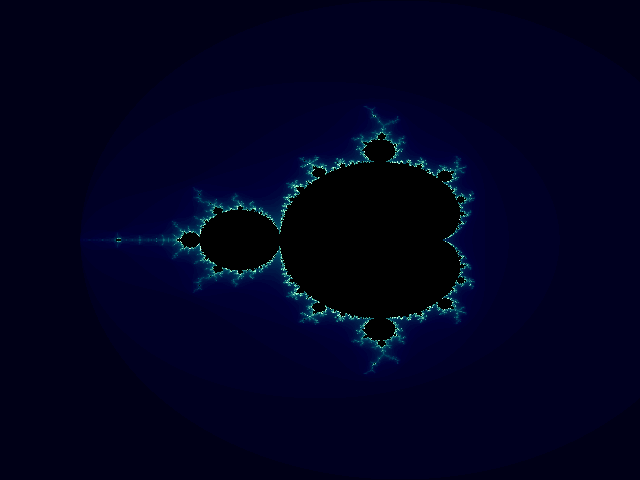

In [ ]:
import torch
import numpy as np
from PIL import Image

# --- Parameters ---
render_size = (640, 480)
center = (-0.5, 0.0)
zoom = 4.0
cycles = 200

width, height = render_size
cx, cy = center

# Build complex plane grid
x = torch.linspace(cx - zoom / 2, cx + zoom / 2, width, device=device)
y = torch.linspace(cy - zoom / 2, cy + zoom / 2, height, device=device)
real, imag = torch.meshgrid(x, y, indexing="xy")
c = torch.complex(real, imag)

# --- Mandelbrot iteration (vectorised, early-escape via masking) ---
z = torch.zeros_like(c)
iter_counts = torch.zeros(height, width, dtype=torch.float32, device=device)
active = torch.ones(height, width, dtype=torch.bool, device=device)

for i in range(1, cycles + 1):
    z_active = z[active]
    c_active = c[active]
    z_new = z_active * z_active + c_active
    z[active] = z_new

    # Escape condition: |z|² > 4  (avoids sqrt)
    escaped_mask = (z_new.real ** 2 + z_new.imag ** 2) > 4.0

    # Map escaped pixels back to global indices and record iteration
    global_escaped = active.clone()
    global_escaped[active] = escaped_mask
    iter_counts[global_escaped] = float(i)

    # Remove newly escaped points from active set
    active[active.clone()] = ~escaped_mask

# iter_counts == 0 means never escaped (interior) → stays 0 (black)
iter_np = iter_counts.cpu().numpy()  # shape: (H, W), float32

# --- Smooth colouring ---
# 1. Normalise only escaped pixels to [0, 1]
escaped = iter_np > 0
smooth = np.zeros_like(iter_np)
smooth[escaped] = iter_np[escaped] / cycles  # linear base

# 2. Apply a gentle gamma curve to spread mid-tones
smooth[escaped] = np.power(smooth[escaped], 0.45)

# 3. Map to a blue/black palette with soft transitions
#    t=0 → escaped just barely (deep blue)  t=1 → escaped fast (bright cyan/white)
t = smooth  # (H, W) in [0, 1], 0 for interior

r = np.clip((t * 1.5 - 0.6) * 255, 0, 255).astype(np.uint8)   # appears late
g = np.clip((t * 1.8 - 0.4) * 255, 0, 255).astype(np.uint8)   # mid-range
b = np.clip( t               * 255, 0, 255).astype(np.uint8)   # always present

# Force interior (never-escaped) to pure black
r[~escaped] = 0
g[~escaped] = 0
b[~escaped] = 0

rgb = np.stack([r, g, b], axis=-1)  # (H, W, 3)
img = Image.fromarray(rgb, mode="RGB")
img

Mandelbrot rendering programs are both simple and infinitely complex at the same time. This view shows the entire Mandelbrot universe simultaneously, as a view completely zoomed out. However, if you zoom in on any non-black portion of the plot, you will find infinite hidden complexity.

## Dealing with Python Warnings

When you encounter warnings in code generated by an AI tool, treat them as early indicators of future problems rather than harmless noise. A practical approach is to copy the exact warning message and include it in a follow-up prompt to the code generator, asking it to revise the code to eliminate the warning. This works well because the model can often recognize deprecated patterns and substitute the modern, supported alternative. Warnings like DeprecationWarning are especially common in AI-generated code because models are trained on large corpora that may include older library usage patterns, even if those patterns are scheduled for removal in upcoming versions. Additionally, libraries such as Pillow evolve over time, and small API changes can trigger warnings even when the code still runs correctly. The warning shown below is a concrete example of this situation, where a parameter is marked for future removal. Addressing warnings early helps ensure forward compatibility, keeps your codebase clean, and prevents subtle bugs or breaking changes when dependencies are upgraded.

```text
/tmp/ipykernel_3284/845830052.py:68: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(rgb, mode="RGB")
```

# Module 2 Assignment

You can find the first assignment here: [assignment 2](https://github.com/jeffheaton/app_deep_learning/blob/main/assignments/assignment_yourname_t81_558_class2.ipynb)